In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from lightgbm import LGBMRegressor, early_stopping


In [2]:
df = pd.read_csv('data/transformed_cleaned_vw_golf.csv')
print(f'Rows: {len(df):,} | Columns: {df.shape[1]}')
df.head()


Rows: 6,920 | Columns: 27


,index,brand,model,registration_date,year,price_in_euro,power_kw,power_ps,fuel_type,fuel_consumption_l_100km,...,T_car_age,color_black,color_blue,color_grey,color_other,color_red,color_silver,color_white,transmission_type_Automatic,transmission_type_Manual
0,213644,volkswagen,Volkswagen Golf,1995-08-01,1995,4970,66,90,Petrol,8.0,...,5.530220,False,True,False,False,False,False,False,False,True
1,213645,volkswagen,Volkswagen Golf,1995-02-01,1995,2590,66,90,Petrol,6.8,...,5.575243,False,True,False,False,False,False,False,True,False
2,213647,volkswagen,Volkswagen Golf,1995-11-01,1995,8900,128,174,Petrol,10.5,...,5.507571,False,True,False,False,False,False,False,True,False
3,213650,volkswagen,Volkswagen Golf,1995-11-01,1995,6399,44,60,Petrol,6.8,...,5.507571,False,True,False,False,False,False,False,False,True
4,213662,volkswagen,Volkswagen Golf,1995-06-01,1995,6600,66,90,Diesel,5.0,...,5.545268,False,False,False,False,True,False,False,False,True


In [3]:
feature_cols = [
    'T_model_age', 'T_car_age', 'T_power_kw', 'T_mileage', 'fuel_consumption_l_100km',
    'transmission_type_Automatic', 'transmission_type_Manual',
    'color_black', 'color_blue', 'color_grey', 'color_other', 'color_red',
    'color_silver', 'color_white'
]

X = df[feature_cols].astype(float)
y = np.log1p(df['price_in_euro'].astype(float))


In [4]:
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.25, random_state=42
)

print('Train:', X_train.shape, 'Validation:', X_val.shape, 'Test:', X_test.shape)


Train: (4152, 14) Validation: (1384, 14) Test: (1384, 14)


In [5]:
lgbm = LGBMRegressor(
    objective='regression',
    n_estimators=2000,
    learning_rate=0.03,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0,
    random_state=42,
    verbose=-1,
)

lgbm.fit(
    X_train,
    y_train,
    eval_set=[(X_val, y_val)],
    eval_metric='l2',
    callbacks=[early_stopping(stopping_rounds=50, verbose=False)],
)


,boosting_type,'gbdt'
,num_leaves,31
,max_depth,6
,learning_rate,0.03
,n_estimators,2000
,subsample_for_bin,200000
,objective,'regression'
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [6]:
def invert_log(y_log):
    return np.expm1(y_log)

def evaluate(y_true_log, y_pred_log, label=''):
    y_true = invert_log(y_true_log)
    y_pred = invert_log(y_pred_log)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    print(f'{label} RMSE: {rmse:.2f}, R²: {r2:.3f}')
    return y_true, y_pred

train_true, train_pred = evaluate(y_train, lgbm.predict(X_train), 'Train')
val_true, val_pred = evaluate(y_val, lgbm.predict(X_val), 'Validation')
test_true, test_pred = evaluate(y_test, lgbm.predict(X_test), 'Test')


Train RMSE: 2684.54, R²: 0.918
Validation RMSE: 3968.37, R²: 0.818
Test RMSE: 2720.61, R²: 0.904


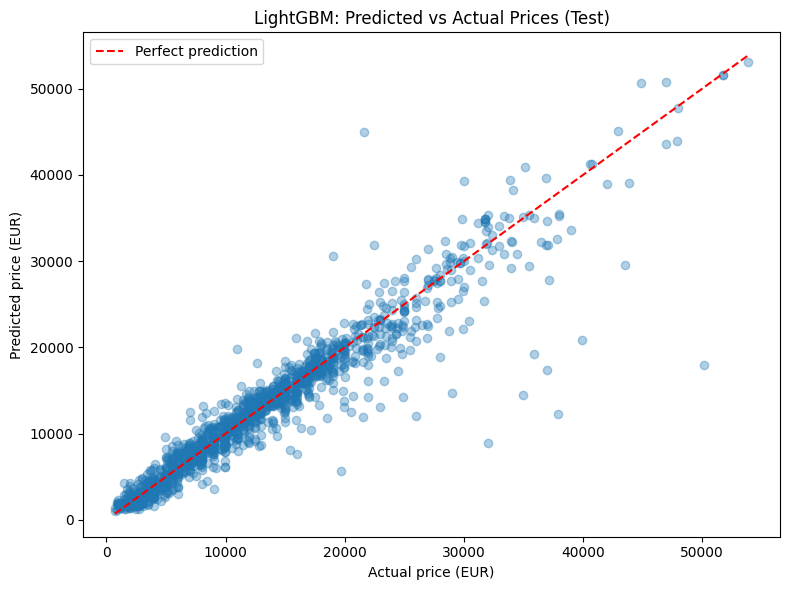

In [7]:
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(test_true, test_pred, alpha=0.35)
min_v = min(test_true.min(), test_pred.min())
max_v = max(test_true.max(), test_pred.max())
ax.plot([min_v, max_v], [min_v, max_v], color='red', linestyle='--', label='Perfect prediction')
ax.set_title('LightGBM: Predicted vs Actual Prices (Test)')
ax.set_xlabel('Actual price (EUR)')
ax.set_ylabel('Predicted price (EUR)')
ax.legend()
plt.tight_layout()
plt.show()


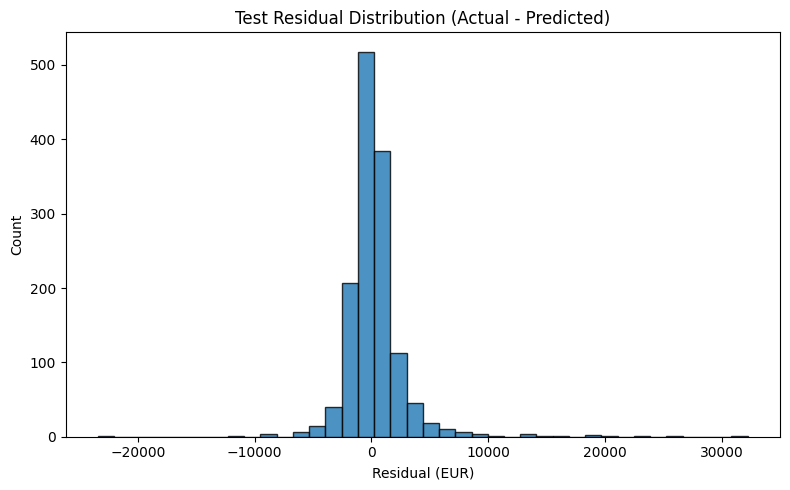

In [8]:
residuals = test_true - test_pred
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(residuals, bins=40, edgecolor='black', alpha=0.8)
ax.set_title('Test Residual Distribution (Actual - Predicted)')
ax.set_xlabel('Residual (EUR)')
ax.set_ylabel('Count')
plt.tight_layout()
plt.show()


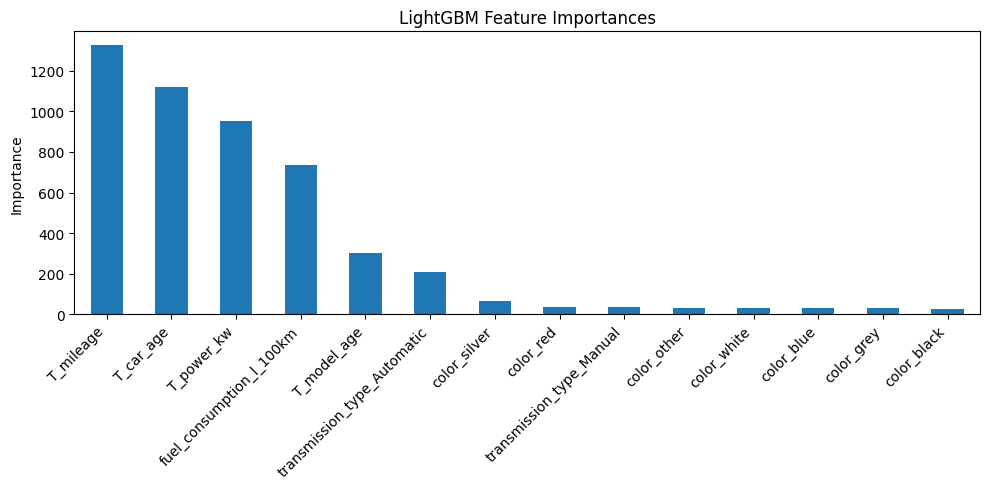

T_mileage                      1328
T_car_age                      1119
T_power_kw                      952
fuel_consumption_l_100km        738
T_model_age                     301
transmission_type_Automatic     211
color_silver                     64
color_red                        37
transmission_type_Manual         35
color_other                      32
color_white                      30
color_blue                       29
color_grey                       29
color_black                      27
dtype: int32

In [9]:
importances = pd.Series(lgbm.feature_importances_, index=feature_cols).sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(10, 5))
importances.plot(kind='bar', ax=ax)
ax.set_title('LightGBM Feature Importances')
ax.set_ylabel('Importance')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

importances
